**EXPECTED INPUTS**

- Temperature Stress: (e.g., Ambient temperature in Celsius).

- Humidity/Contamination: (e.g., Air moisture or powder purity).

- Operational Load: (e.g., Total print hours or cycles completed).

- Maintenance Level: (e.g., A coefficient representing how well the machine is being cared for).


**EXPECTED OUTPUTS**

- Health Index: A normalized value (e.g., 0.0 to 1.0) representing the component's remaining life.

- Operational Status: A *categorical* state (e.g., FUNCTIONAL, DEGRADED, CRITICAL, or FAILED).

- Component Metrics: Custom physical variables defined by your model (e.g., if modeling a blade, this could be 'thickness'; if a resistor, 'resistance').


----------------------------------

In [5]:
# Install required packages for this notebook (if running in colab/local and not already installed)
import sys
import subprocess

def install_and_import(package, import_name=None):
    try:
        __import__(import_name if import_name else package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        __import__(import_name if import_name else package)

# List of required pip packages and their (optionally different) import names
required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scipy", "scipy"),
    ("sqlite3", "sqlite3")  # Note: sqlite3 is part of the standard library, should not need installation.
]
for pip_name, import_name in required_packages:
    if pip_name != "sqlite3":   # skip installation for standard library
        install_and_import(pip_name, import_name)

Installing numpy...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 11.5 MB/s  0:00:00 eta 0:00:01
Installing pandas...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.0 MB/s  0:00:00 eta 0:00:01
Installing matplotlib...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 12.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 9.3 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Installing seaborn...
Installing scipy...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 11.5 MB/s  0:00:01 eta 0:00:01


In [6]:

import sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

DB_PATH = "/Users/pablocpz/Desktop/HackUPC26/data/simulation.db"

with sqlite3.connect(DB_PATH) as con:
    df = pd.read_sql("SELECT * FROM simulation_log", con)

# ── typed columns ─────────────────────────────────────────────────────────────
SCENARIOS   = df["scenario_id"].unique().tolist()
COMPONENTS  = ["blade","motor","rail","nozzle","resistor","cleaning","heater","sensor","insulation"]
SUBSYSTEMS  = {"Recoating":["blade","motor","rail"],
               "Printhead":["nozzle","resistor","cleaning"],
               "Thermal":  ["heater","sensor","insulation"]}
METRICS     = {"blade":"metric_blade_mm","motor":"metric_motor_vib","rail":"metric_rail_dev",
               "nozzle":"metric_nozzle_clog","resistor":"metric_resistor_pct","cleaning":"metric_cleaning_eff",
               "heater":"metric_heater_ohm","sensor":"metric_sensor_err","insulation":"metric_insulation_r"}
METRIC_UNITS= {"blade":"mm (thickness)","motor":"mm/s (vibration)","rail":"µm (deviation)",
               "nozzle":"clog prob.","resistor":"% drift","cleaning":"efficiency",
               "heater":"Ω","sensor":"°C error","insulation":"°C·m/W"}
LABEL_NAMES = {0:"FUNCTIONAL",1:"DEGRADED",2:"CRITICAL",3:"FAILED"}
LABEL_COLORS= {0:"#2ecc71",1:"#f39c12",2:"#e67e22",3:"#e74c3c"}

STATUS_ORDER = ["FUNCTIONAL","DEGRADED","CRITICAL","FAILED"]

df["scenario_id"] = df["scenario_id"].astype("category")
for c in COMPONENTS:
    df[f"label_{c}"] = df[f"label_{c}"].astype("Int8")

print(f"Rows: {len(df):,}  |  Scenarios: {len(SCENARIOS)}  |  Runs: {df['run_id'].nunique()}  |  Timesteps/run: {df['t'].max()+1}")
df.head(3)


Rows: 100,000  |  Scenarios: 5  |  Runs: 20  |  Timesteps/run: 1000


,id,scenario_id,run_id,t,temperature,humidity,load,maintenance,is_shock,health_blade,...,label_motor,label_rail,label_nozzle,label_resistor,label_cleaning,label_heater,label_sensor,label_insulation,action_taken,reward
0,1,baseline_nominal,0,0,20.00,0.4,0.0,0.5,0,1.000000,...,0,0,0,0,0,0,0,0,None,None
1,2,baseline_nominal,0,1,20.03,0.4,1.0,0.0,0,0.996894,...,0,0,0,0,0,0,0,0,None,None
2,3,baseline_nominal,0,2,20.06,0.4,2.0,0.0,0,0.993796,...,0,0,0,0,0,0,0,0,None,None


---
## 1 — Dataset Overview


In [7]:

# ── Basic stats ───────────────────────────────────────────────────────────────
print("=== Shape & dtypes ===")
print(df.shape)
print(df.dtypes.to_string())
print("\n=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() or "None")
print("\n=== Numeric summary (inputs + aggregate healths) ===")
cols_summary = ["temperature","humidity","load","maintenance","is_shock",
                "health_recoating","health_printhead","health_thermal"]
df[cols_summary].describe().round(4)


=== Shape & dtypes ===
(100000, 50)
id                        int64
scenario_id            category
run_id                    int64
t                         int64
temperature             float64
humidity                float64
load                    float64
maintenance             float64
is_shock                  int64
health_blade            float64
health_motor            float64
health_rail             float64
status_blade                str
status_motor                str
status_rail                 str
metric_blade_mm         float64
metric_motor_vib        float64
metric_rail_dev         float64
health_nozzle           float64
health_resistor         float64
health_cleaning         float64
status_nozzle               str
status_resistor             str
status_cleaning             str
metric_nozzle_clog      float64
metric_resistor_pct     float64
metric_cleaning_eff     float64
health_heater           float64
health_sensor           float64
health_insulation       float64
stat

,temperature,humidity,load,maintenance,is_shock,health_recoating,health_printhead,health_thermal
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,35.0843,0.4023,499.5000,0.0035,0.0122,0.3523,0.4772,0.6204
std,8.9038,0.0470,288.6764,0.0523,0.1097,0.2714,0.3563,0.2549
min,15.0000,0.1193,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,27.5468,0.4000,249.7500,0.0000,0.0000,0.1058,0.0486,0.4458
50%,35.0300,0.4000,499.5000,0.0000,0.0000,0.3167,0.5844,0.6725
75%,42.5765,0.4000,749.2500,0.0000,0.0000,0.5493,0.8026,0.8323
max,70.0000,1.0000,999.0000,1.0000,1.0000,1.0000,1.0000,1.0000


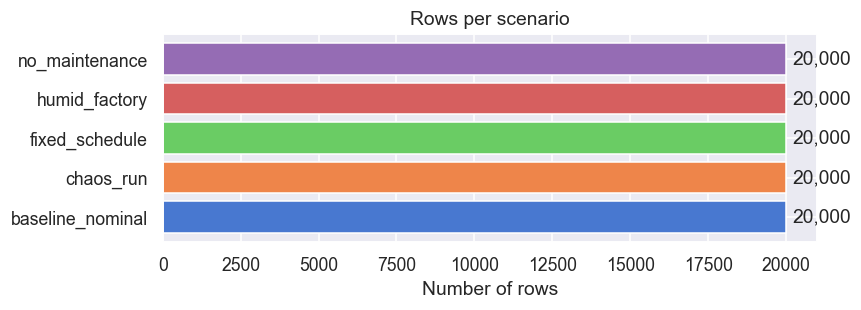

In [8]:

# ── Rows per scenario ─────────────────────────────────────────────────────────
counts = df.groupby("scenario_id", observed=True).size().reset_index(name="rows")
fig, ax = plt.subplots(figsize=(8,3))
bars = ax.barh(counts["scenario_id"], counts["rows"], color=sns.color_palette("muted", len(counts)))
ax.bar_label(bars, fmt="{:,.0f}", padding=4)
ax.set_xlabel("Number of rows")
ax.set_title("Rows per scenario")
plt.tight_layout(); plt.show()


---
## 2 — Input Feature Analysis
### 2.1 — Global distributions (all scenarios combined)


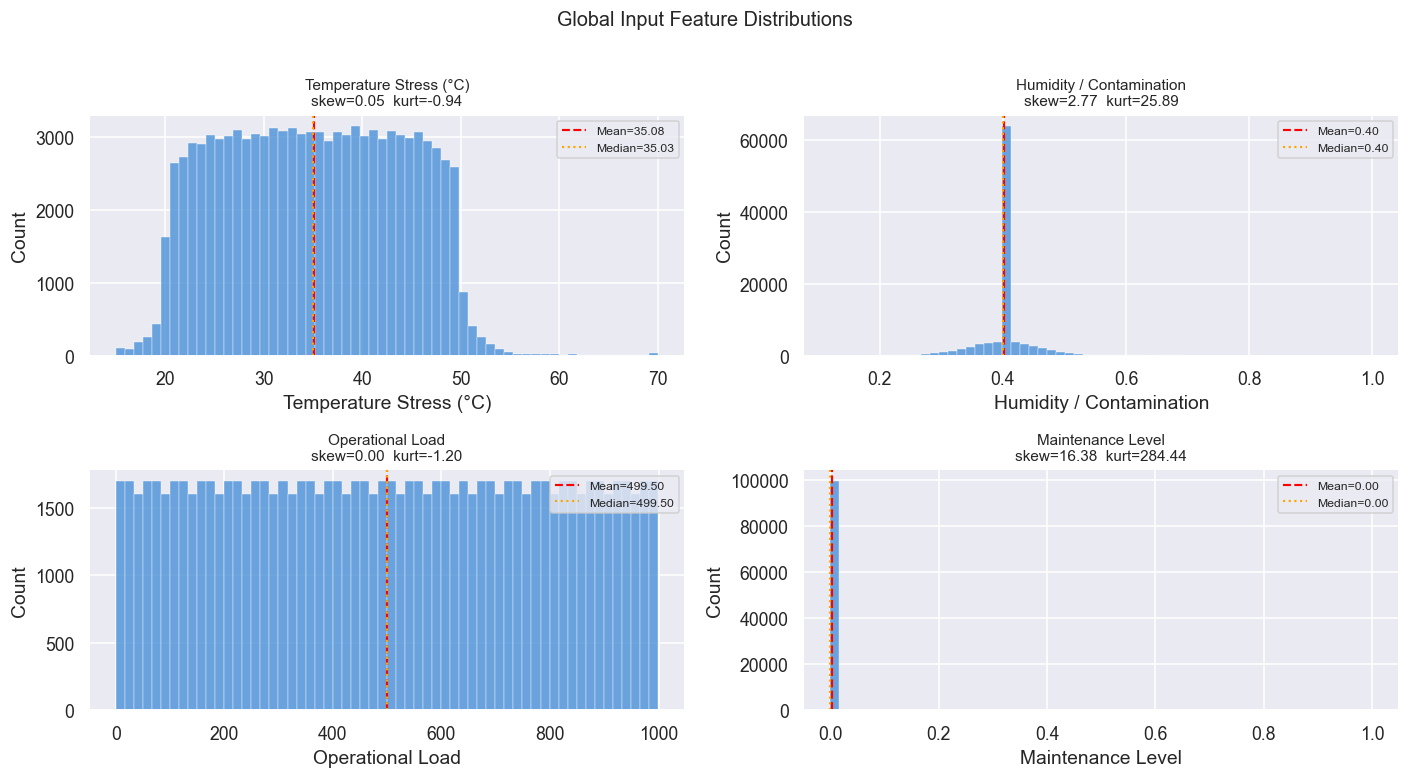

In [9]:

INPUT_COLS   = ["temperature","humidity","load","maintenance"]
INPUT_LABELS = ["Temperature Stress (°C)","Humidity / Contamination",
                "Operational Load","Maintenance Level"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.ravel()

for ax, col, label in zip(axes, INPUT_COLS, INPUT_LABELS):
    data = df[col].dropna()
    ax.hist(data, bins=60, color="#4a90d9", alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(data.mean(), color="red",    linestyle="--", linewidth=1.4, label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color="orange", linestyle=":",  linewidth=1.4, label=f"Median={data.median():.2f}")
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    ax.set_title(f"{label}\nskew={skew:.2f}  kurt={kurt:.2f}", fontsize=10)
    ax.set_xlabel(label); ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Global Input Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 2.2 — Input distributions per scenario (box + violin)


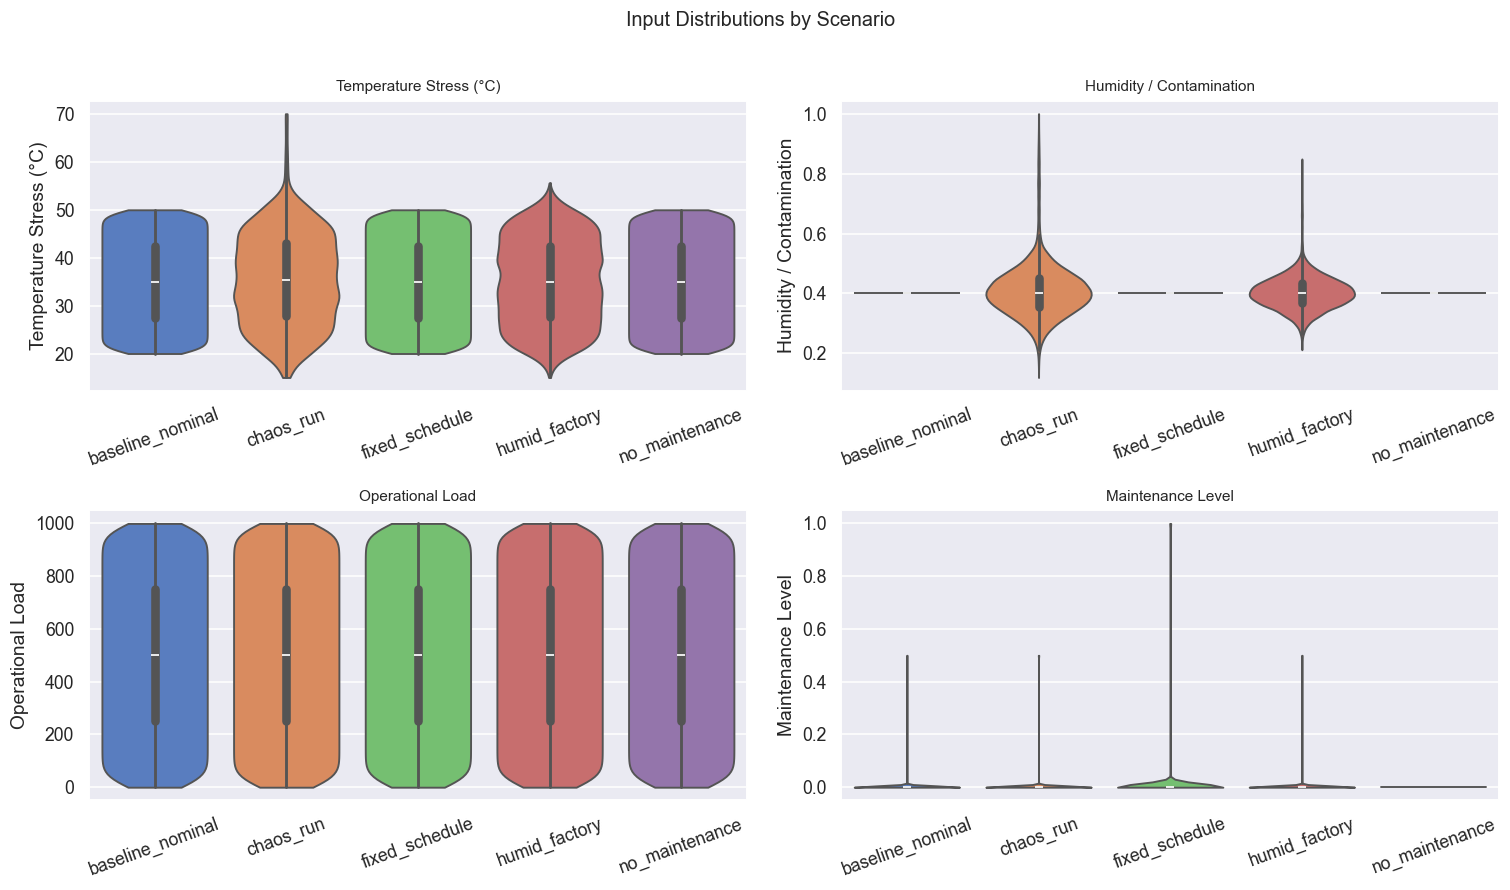

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, col, label in zip(axes, INPUT_COLS, INPUT_LABELS):
    sns.violinplot(data=df, x="scenario_id", y=col, ax=ax,
                   palette="muted", inner="box", cut=0)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Input Distributions by Scenario", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 2.3 — Mean input level per scenario (heatmap)


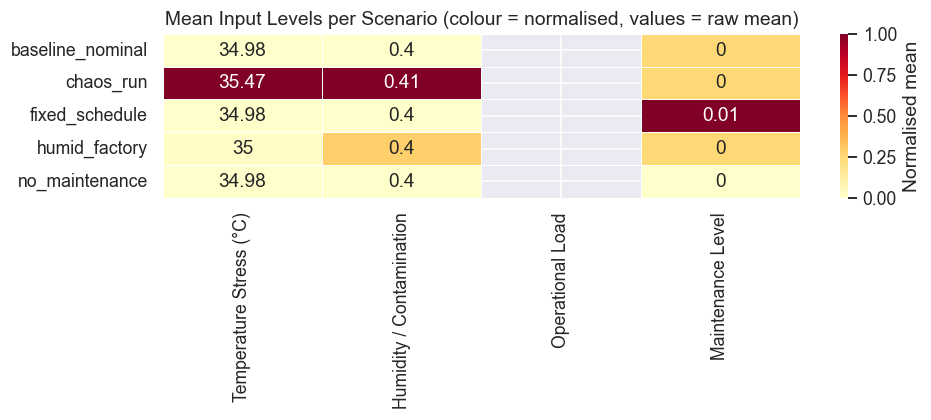

In [11]:

pivot = df.groupby("scenario_id", observed=True)[INPUT_COLS].mean()
pivot.columns = INPUT_LABELS
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())   # 0-1 per feature

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot_norm, annot=pivot.round(2), fmt="g", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label":"Normalised mean"})
ax.set_title("Mean Input Levels per Scenario (colour = normalised, values = raw mean)")
ax.set_ylabel("")
plt.tight_layout(); plt.show()


### 2.4 — Temporal evolution of inputs (mean ± std across runs, baseline_nominal)


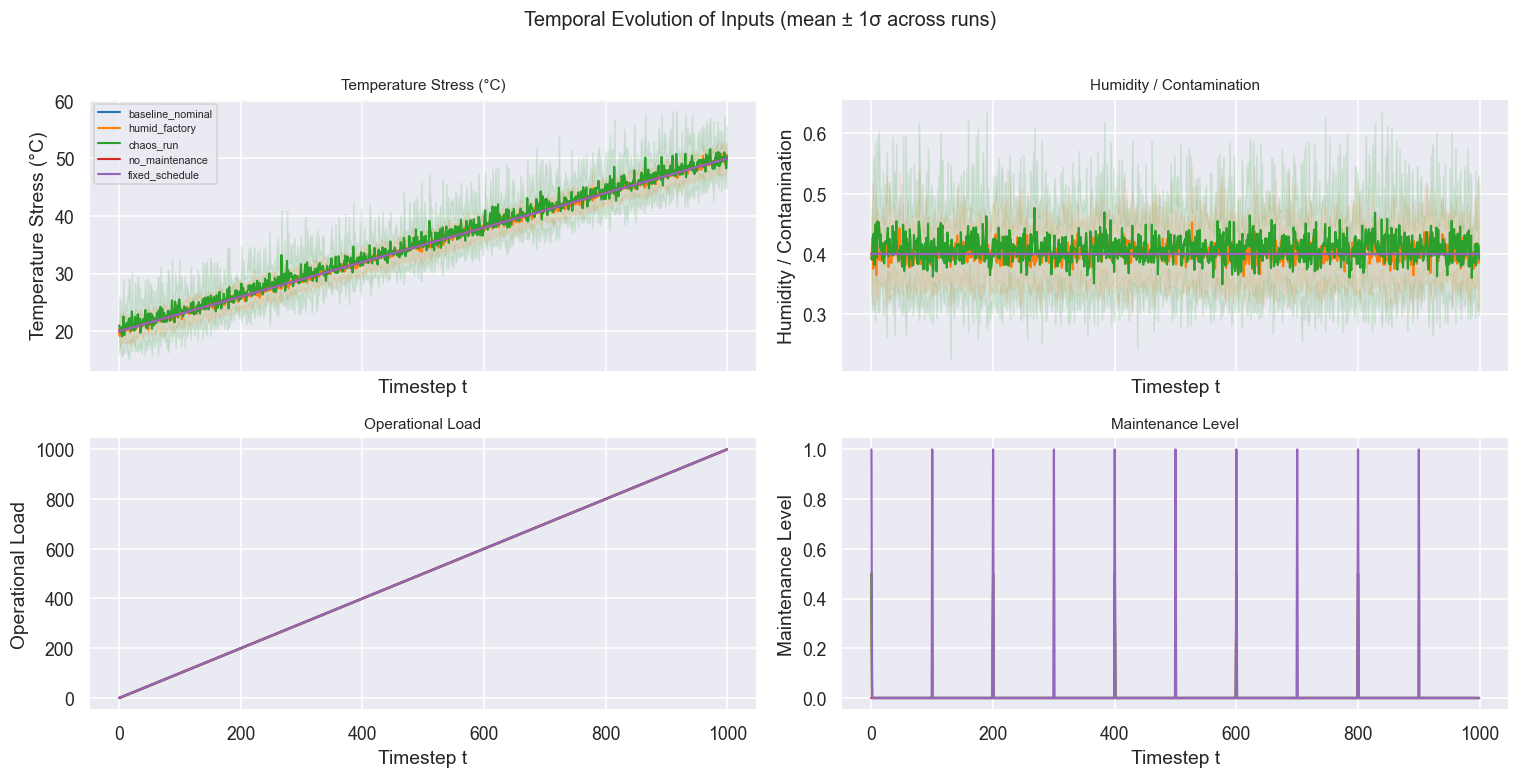

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
axes = axes.ravel()
palette = sns.color_palette("tab10", len(SCENARIOS))

for ax, col, label in zip(axes, INPUT_COLS, INPUT_LABELS):
    for scen, color in zip(SCENARIOS, palette):
        grp = df[df["scenario_id"]==scen].groupby("t")[col]
        mn, sd = grp.mean(), grp.std()
        ax.plot(mn.index, mn.values, label=scen, color=color, linewidth=1.4)
        ax.fill_between(mn.index, mn-sd, mn+sd, alpha=0.12, color=color)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(label)
    ax.set_xlabel("Timestep t")

axes[0].legend(fontsize=7, loc="upper left")
plt.suptitle("Temporal Evolution of Inputs (mean ± 1σ across runs)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 2.5 — Shock event frequency per scenario


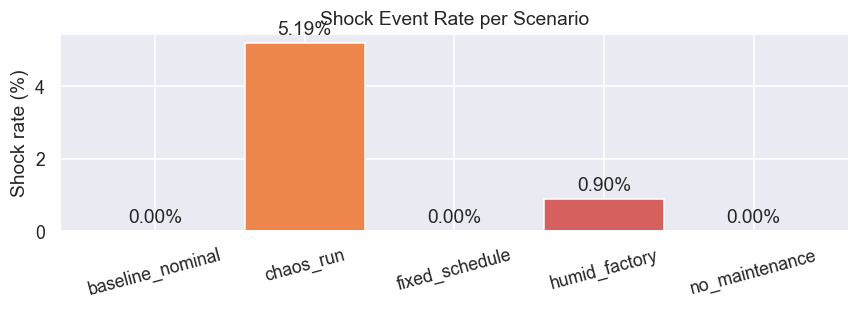

In [13]:

shock_rate = df.groupby("scenario_id", observed=True)["is_shock"].mean().mul(100).round(2)
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(shock_rate.index, shock_rate.values, color=sns.color_palette("muted", len(shock_rate)))
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.set_ylabel("Shock rate (%)")
ax.set_title("Shock Event Rate per Scenario")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()


---
## 3 — Output Analysis: Health Index (per component)
### 3.1 — Health index distributions (all 9 components, all scenarios)


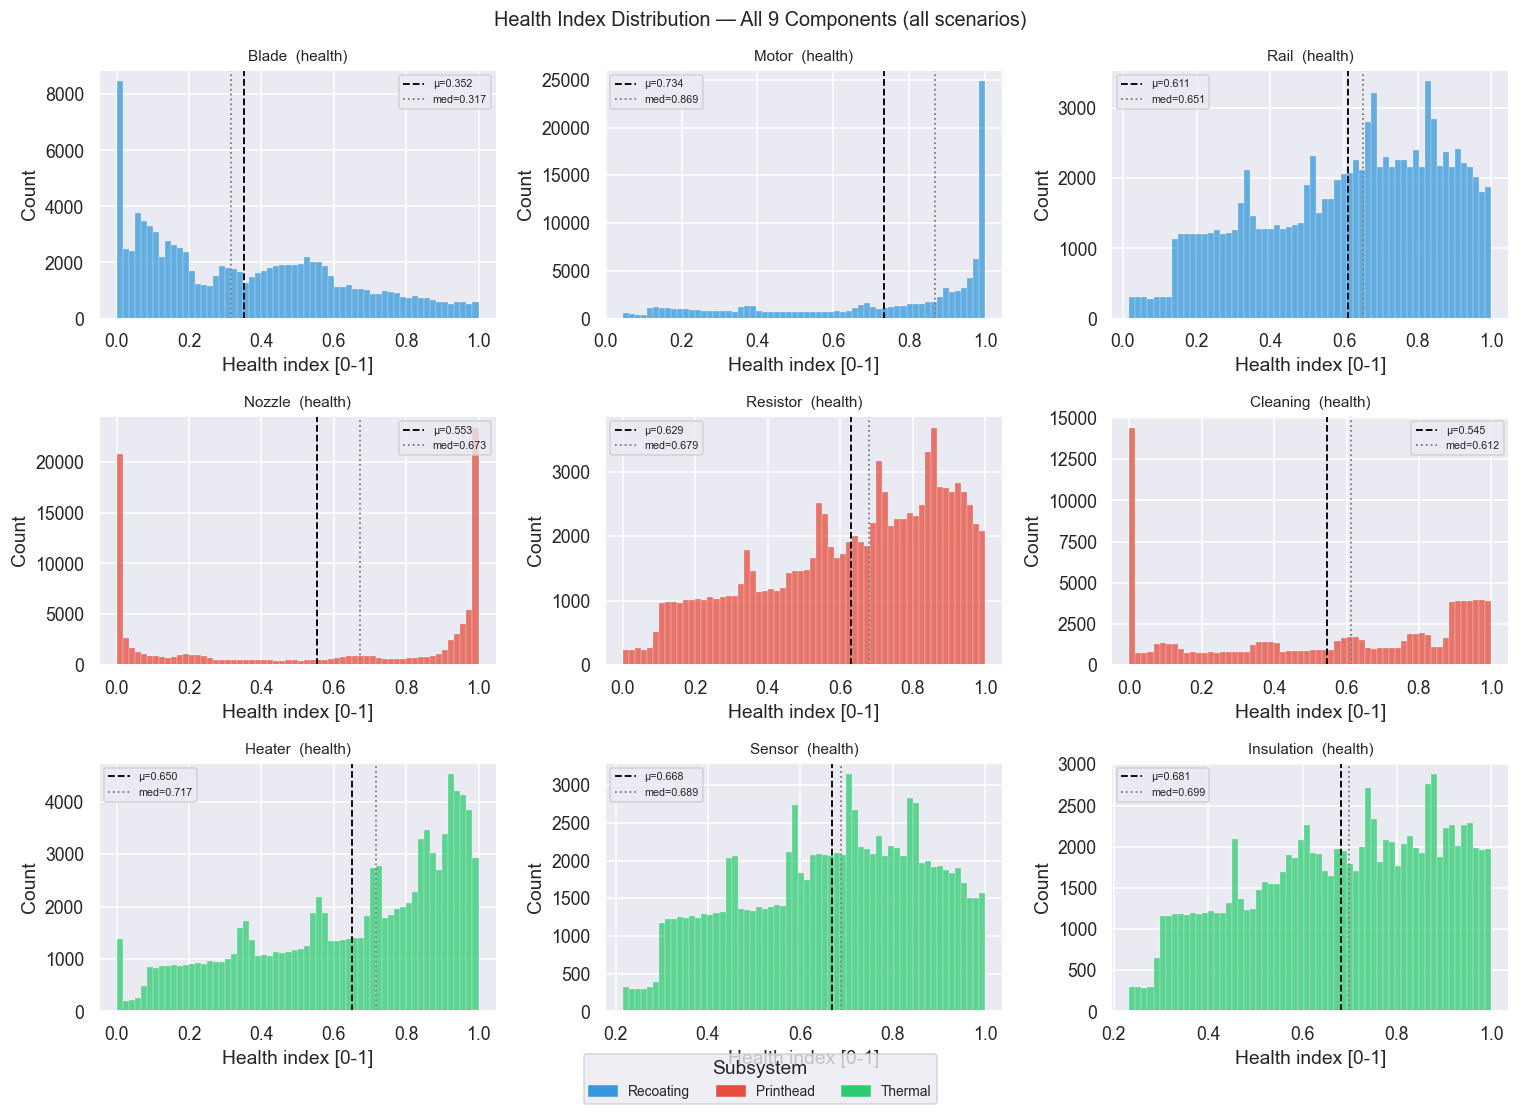

In [14]:

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
subsys_colors = {"Recoating":"#3498db","Printhead":"#e74c3c","Thermal":"#2ecc71"}
comp_color = {c: subsys_colors[ss] for ss, comps in SUBSYSTEMS.items() for c in comps}

for ax, comp in zip(axes.ravel(), COMPONENTS):
    col = f"health_{comp}"
    data = df[col].dropna()
    ax.hist(data, bins=60, color=comp_color[comp], alpha=0.75, edgecolor="white", linewidth=0.2)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.2, label=f"μ={data.mean():.3f}")
    ax.axvline(data.median(), color="grey",  linestyle=":",  linewidth=1.2, label=f"med={data.median():.3f}")
    ax.set_title(f"{comp.capitalize()}  (health)", fontsize=10)
    ax.set_xlabel("Health index [0-1]"); ax.set_ylabel("Count")
    ax.legend(fontsize=7)

# Legend for subsystems
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k,v in subsys_colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, title="Subsystem",
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Health Index Distribution — All 9 Components (all scenarios)", fontsize=13)
plt.tight_layout(); plt.show()


### 3.2 — Health index by scenario (violin, all 9 components)


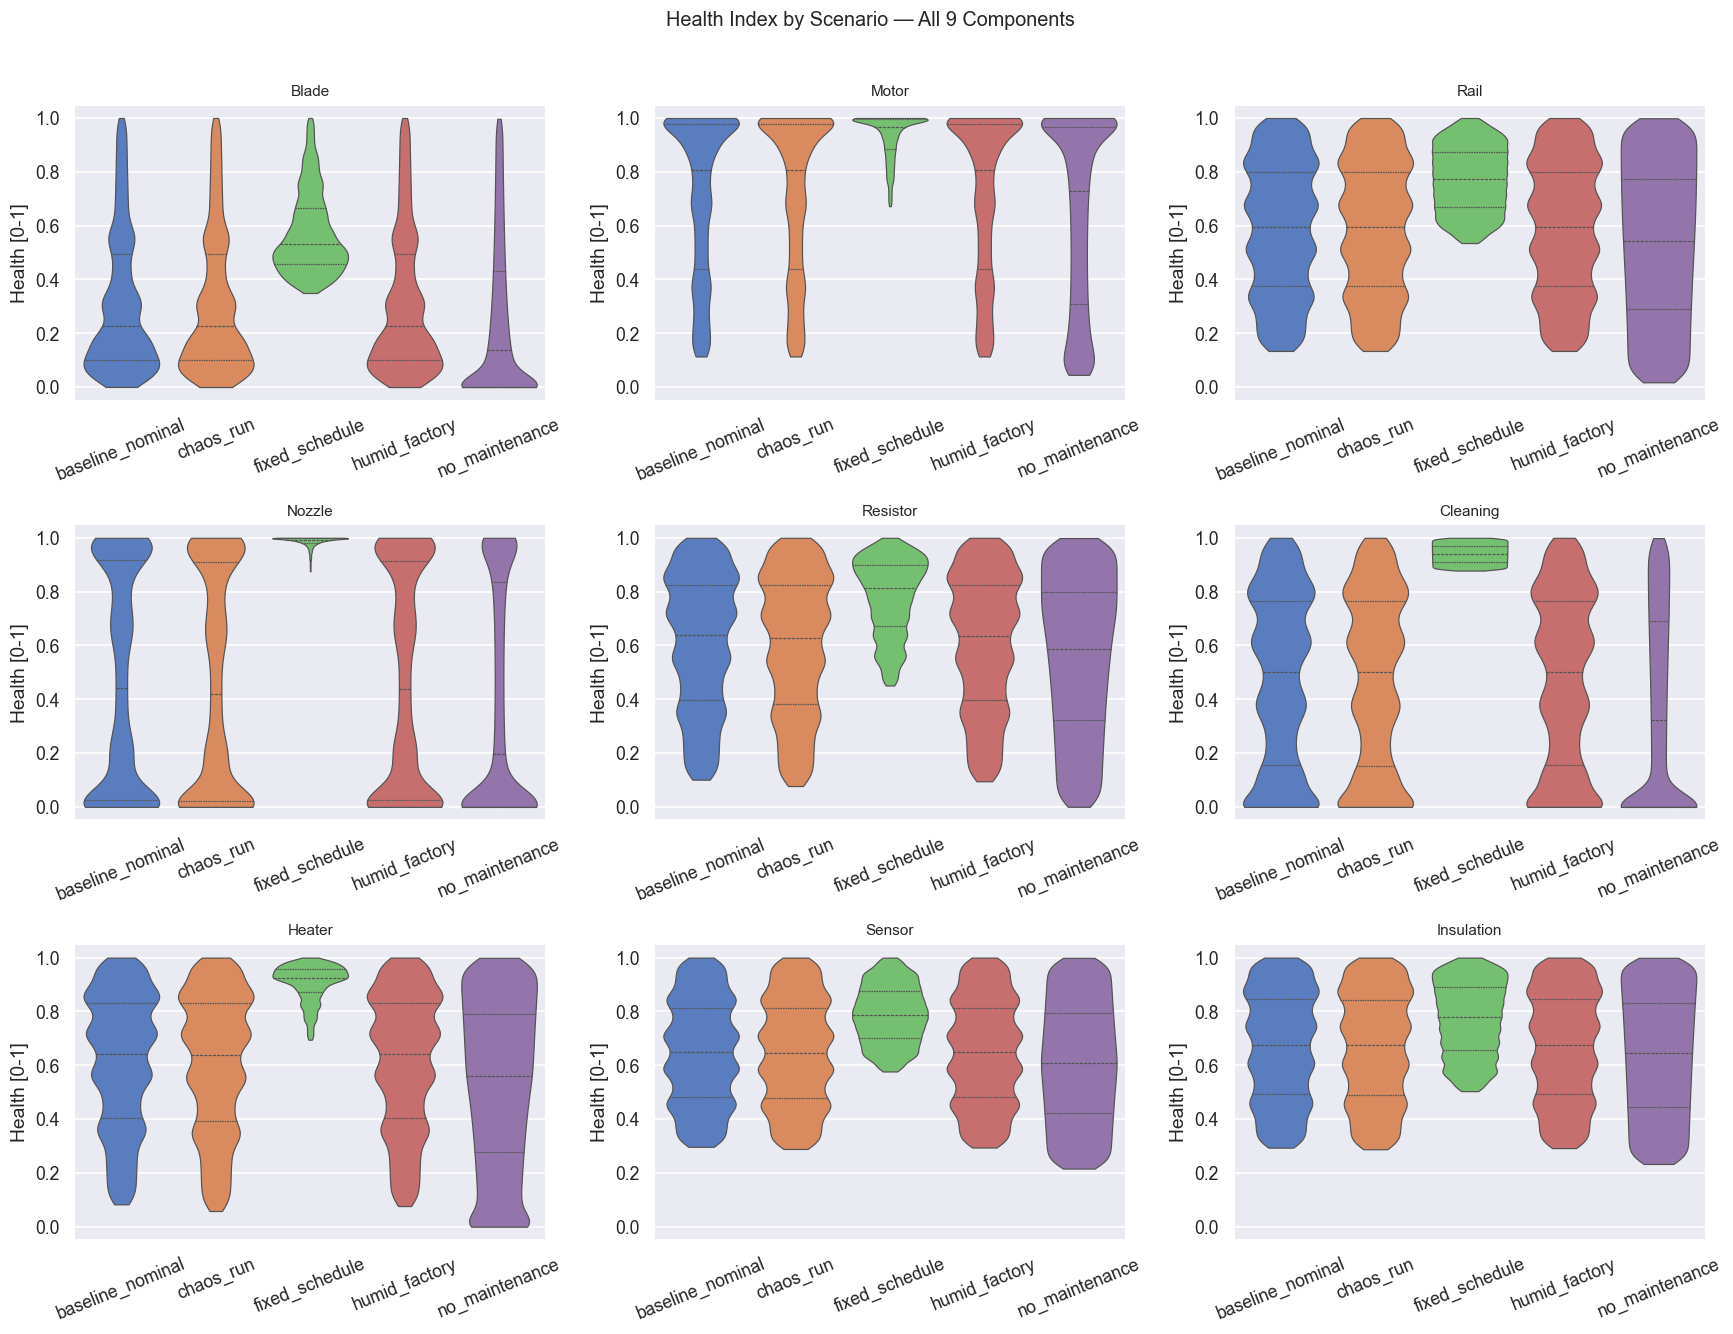

In [15]:

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, comp in zip(axes.ravel(), COMPONENTS):
    col = f"health_{comp}"
    sns.violinplot(data=df, x="scenario_id", y=col, ax=ax,
                   palette="muted", inner="quartile", cut=0, linewidth=0.8)
    ax.set_title(f"{comp.capitalize()}", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("Health [0-1]")
    ax.tick_params(axis="x", rotation=22)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle("Health Index by Scenario — All 9 Components", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 3.3 — Health index temporal degradation (mean across runs, per scenario)


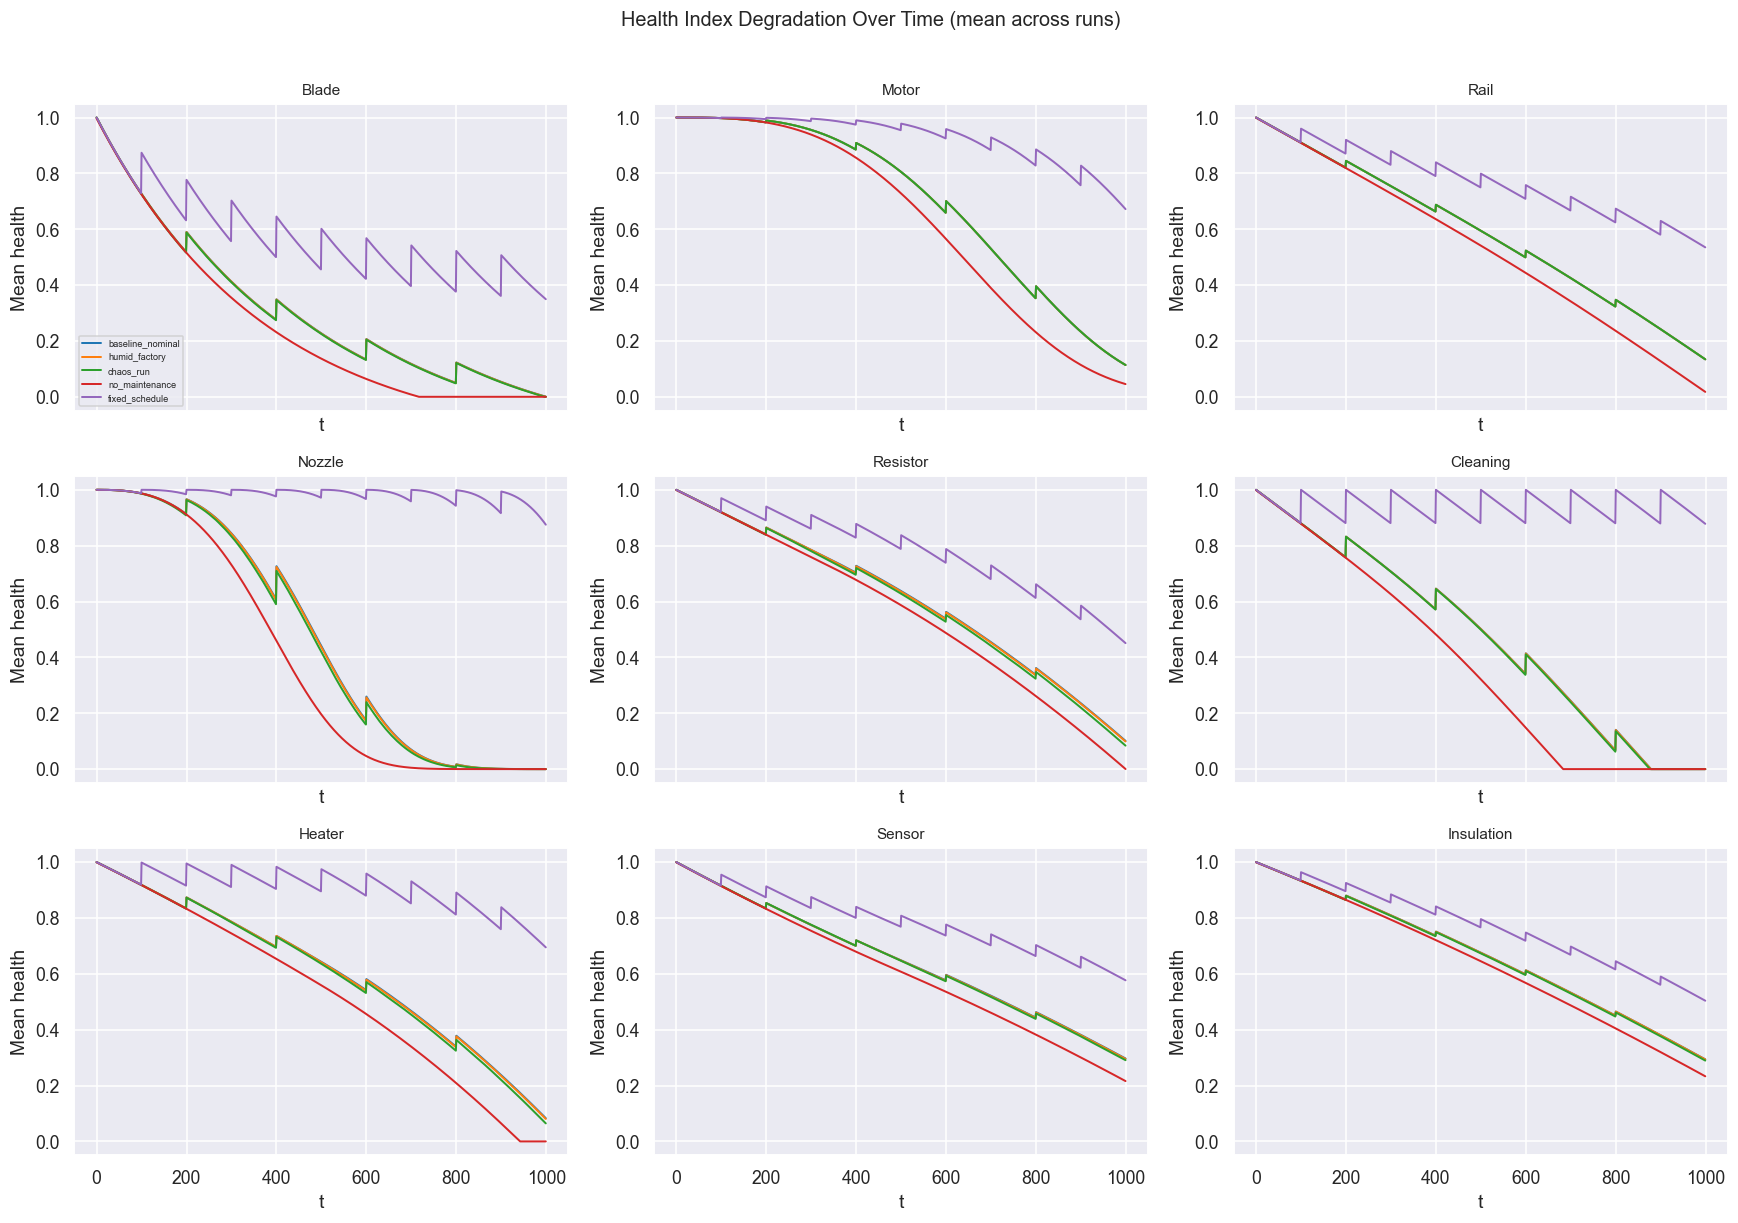

In [16]:

fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)

for ax, comp in zip(axes.ravel(), COMPONENTS):
    col = f"health_{comp}"
    for scen, color in zip(SCENARIOS, palette):
        grp = df[df["scenario_id"]==scen].groupby("t")[col].mean()
        ax.plot(grp.index, grp.values, label=scen, color=color, linewidth=1.3)
    ax.set_title(f"{comp.capitalize()}", fontsize=10)
    ax.set_ylabel("Mean health"); ax.set_xlabel("t")
    ax.set_ylim(-0.05, 1.05)

axes[0][0].legend(fontsize=6, loc="lower left")
plt.suptitle("Health Index Degradation Over Time (mean across runs)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


---
## 4 — Output Analysis: Operational Status & Labels
### 4.1 — Label distribution per component (stacked bar)


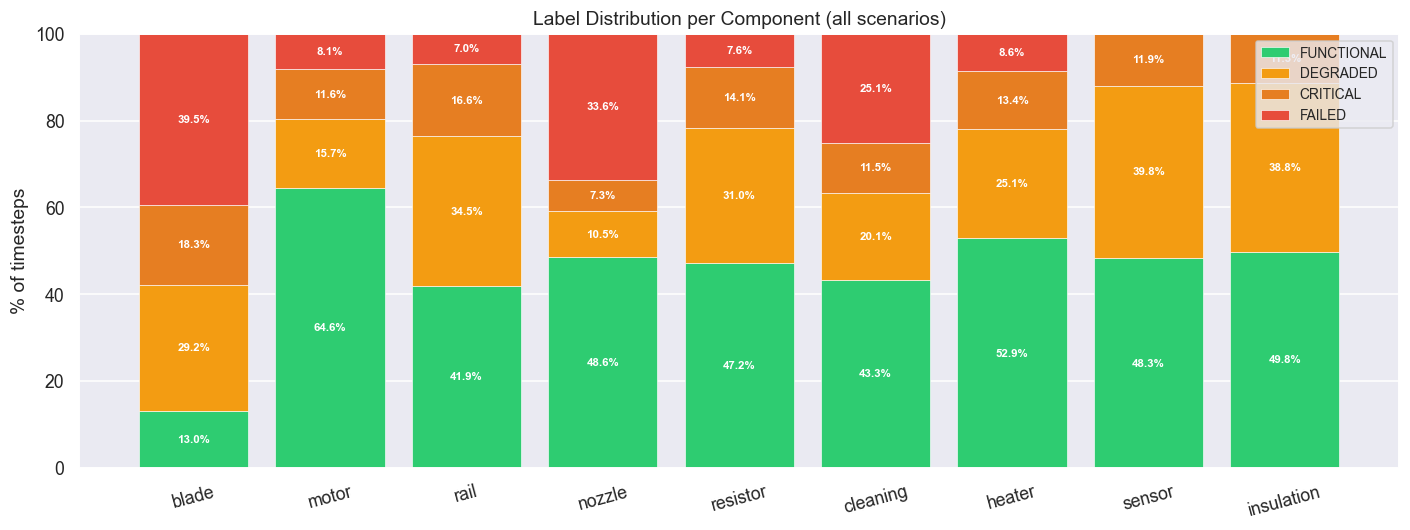

In [17]:

label_pcts = {}
for comp in COMPONENTS:
    vc = df[f"label_{comp}"].value_counts(normalize=True).sort_index()
    label_pcts[comp] = vc

label_df = pd.DataFrame(label_pcts).T.fillna(0) * 100
label_df.columns = [LABEL_NAMES[c] for c in sorted(label_df.columns)]

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(COMPONENTS))
colors_list = [LABEL_COLORS[i] for i in sorted(LABEL_COLORS)]

for (status, col_data), color in zip(label_df.items(), colors_list):
    vals = col_data.values
    bars = ax.bar(label_df.index, vals, bottom=bottom, label=status, color=color, edgecolor="white", linewidth=0.4)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 4:
            ax.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                    f"{val:.1f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    bottom += vals

ax.set_ylabel("% of timesteps")
ax.set_title("Label Distribution per Component (all scenarios)")
ax.legend(loc="upper right", fontsize=9)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()


### 4.2 — Label distribution per component × scenario (heatmap of FAILED %)


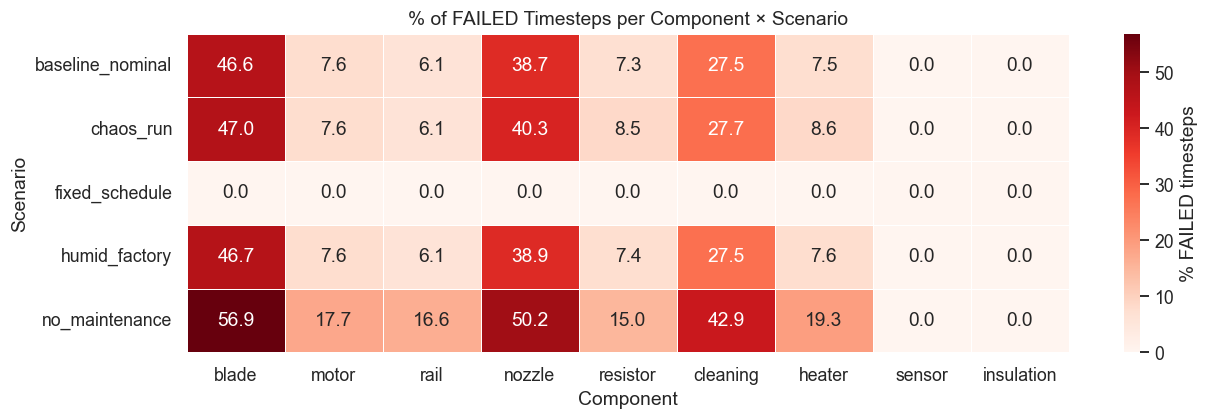

In [18]:

failed_pct = {}
for comp in COMPONENTS:
    col = f"label_{comp}"
    grp = df.groupby("scenario_id", observed=True)[col].apply(lambda x: (x==3).mean()*100)
    failed_pct[comp] = grp

failed_df = pd.DataFrame(failed_pct)   # scenarios × components

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(failed_df, annot=True, fmt=".1f", cmap="Reds", linewidths=0.4, ax=ax,
            cbar_kws={"label":"% FAILED timesteps"})
ax.set_title("% of FAILED Timesteps per Component × Scenario")
ax.set_ylabel("Scenario"); ax.set_xlabel("Component")
plt.tight_layout(); plt.show()


### 4.3 — Status transition: fraction of each state over time (per component)


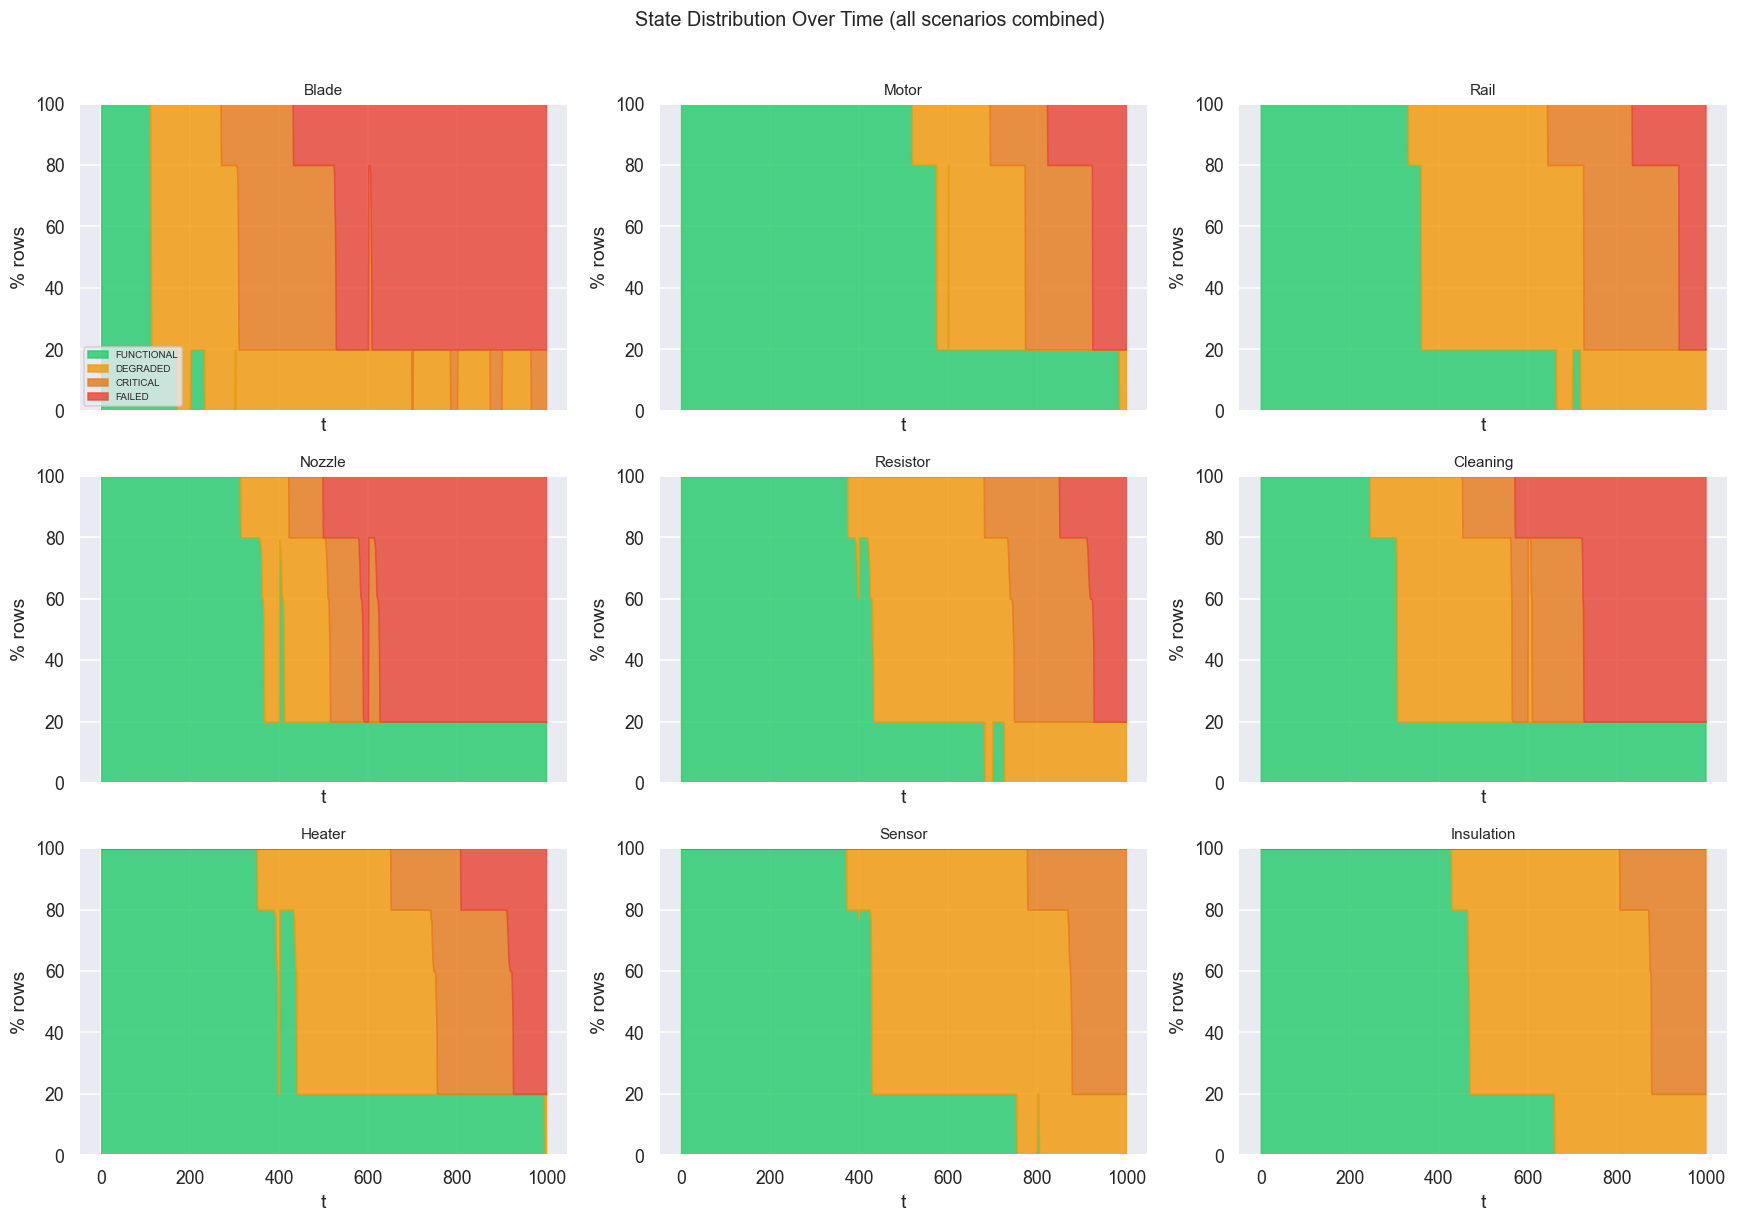

In [19]:

fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)
state_colors_list = [LABEL_COLORS[i] for i in range(4)]

for ax, comp in zip(axes.ravel(), COMPONENTS):
    col = f"label_{comp}"
    time_label = df.groupby("t")[col].value_counts(normalize=True).unstack(fill_value=0)
    # ensure all 4 states present
    for s in range(4):
        if s not in time_label.columns:
            time_label[s] = 0.0
    time_label = time_label[[0,1,2,3]] * 100
    bottom = np.zeros(len(time_label))
    for state, color in zip([0,1,2,3], state_colors_list):
        vals = time_label[state].values
        ax.fill_between(time_label.index, bottom, bottom+vals, color=color, alpha=0.85,
                        label=LABEL_NAMES[state])
        bottom = bottom + vals
    ax.set_title(f"{comp.capitalize()}", fontsize=10)
    ax.set_ylabel("% rows"); ax.set_xlabel("t")
    ax.set_ylim(0, 100)

axes[0][0].legend(fontsize=6.5, loc="lower left")
plt.suptitle("State Distribution Over Time (all scenarios combined)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


---
## 5 — Output Analysis: Component Physical Metrics
### 5.1 — Metric distributions (all 9 components)


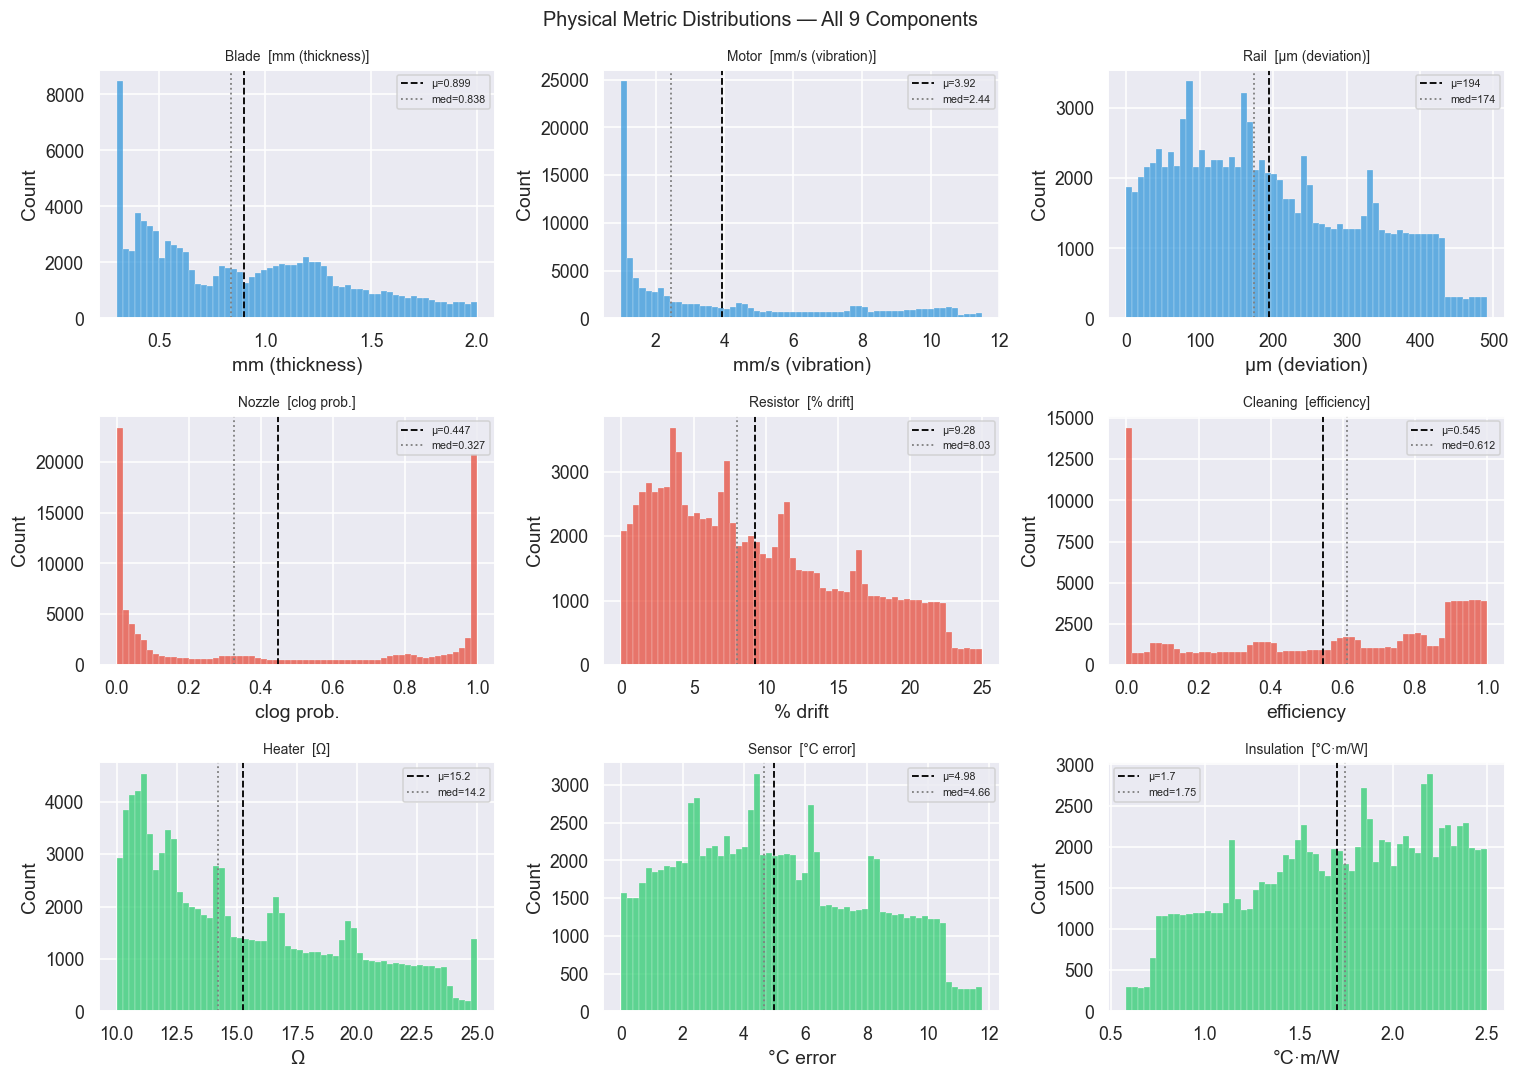

In [20]:

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for ax, comp in zip(axes.ravel(), COMPONENTS):
    col  = METRICS[comp]
    unit = METRIC_UNITS[comp]
    data = df[col].dropna()
    ax.hist(data, bins=60, color=comp_color[comp], alpha=0.75, edgecolor="white", linewidth=0.2)
    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.2, label=f"μ={data.mean():.3g}")
    ax.axvline(data.median(), color="grey",   linestyle=":",  linewidth=1.2, label=f"med={data.median():.3g}")
    ax.set_title(f"{comp.capitalize()}  [{unit}]", fontsize=9)
    ax.set_xlabel(unit); ax.set_ylabel("Count")
    ax.legend(fontsize=7)

plt.suptitle("Physical Metric Distributions — All 9 Components", fontsize=13)
plt.tight_layout(); plt.show()


### 5.2 — Metric by operational status (box per label state)


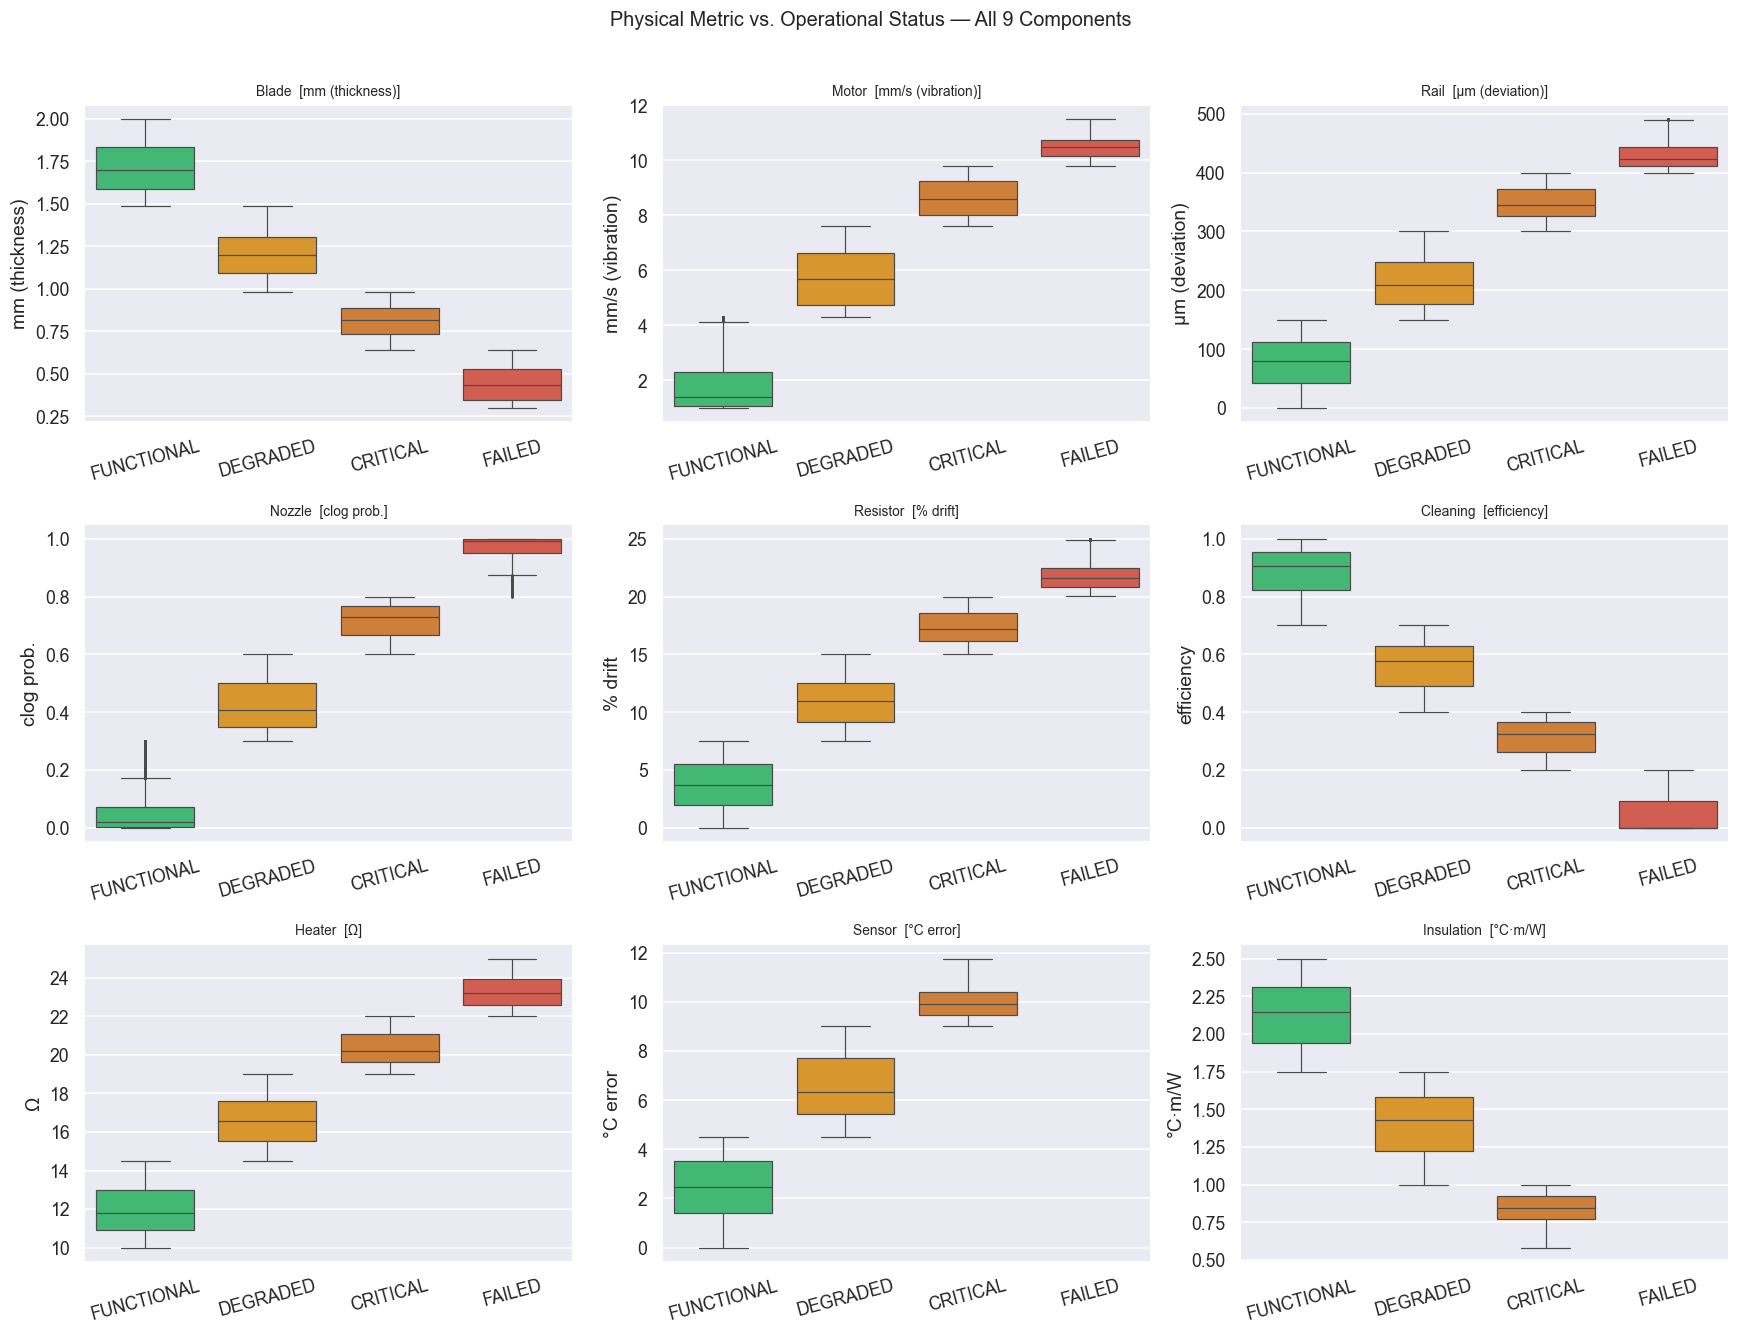

In [21]:

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, comp in zip(axes.ravel(), COMPONENTS):
    metric_col = METRICS[comp]
    label_col  = f"label_{comp}"
    unit = METRIC_UNITS[comp]

    sub = df[[metric_col, label_col]].dropna()
    sub[label_col] = sub[label_col].astype(int)
    sub["Status"] = sub[label_col].map(LABEL_NAMES)
    sub["Status"] = pd.Categorical(sub["Status"], categories=STATUS_ORDER, ordered=True)

    palette_status = {LABEL_NAMES[k]: v for k,v in LABEL_COLORS.items()}
    sns.boxplot(data=sub, x="Status", y=metric_col, ax=ax,
                palette=palette_status, order=STATUS_ORDER,
                flierprops=dict(marker=".", markersize=1, alpha=0.3), linewidth=0.8)
    ax.set_title(f"{comp.capitalize()}  [{unit}]", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel(unit)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Physical Metric vs. Operational Status — All 9 Components", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 5.3 — Physical metric temporal evolution per scenario


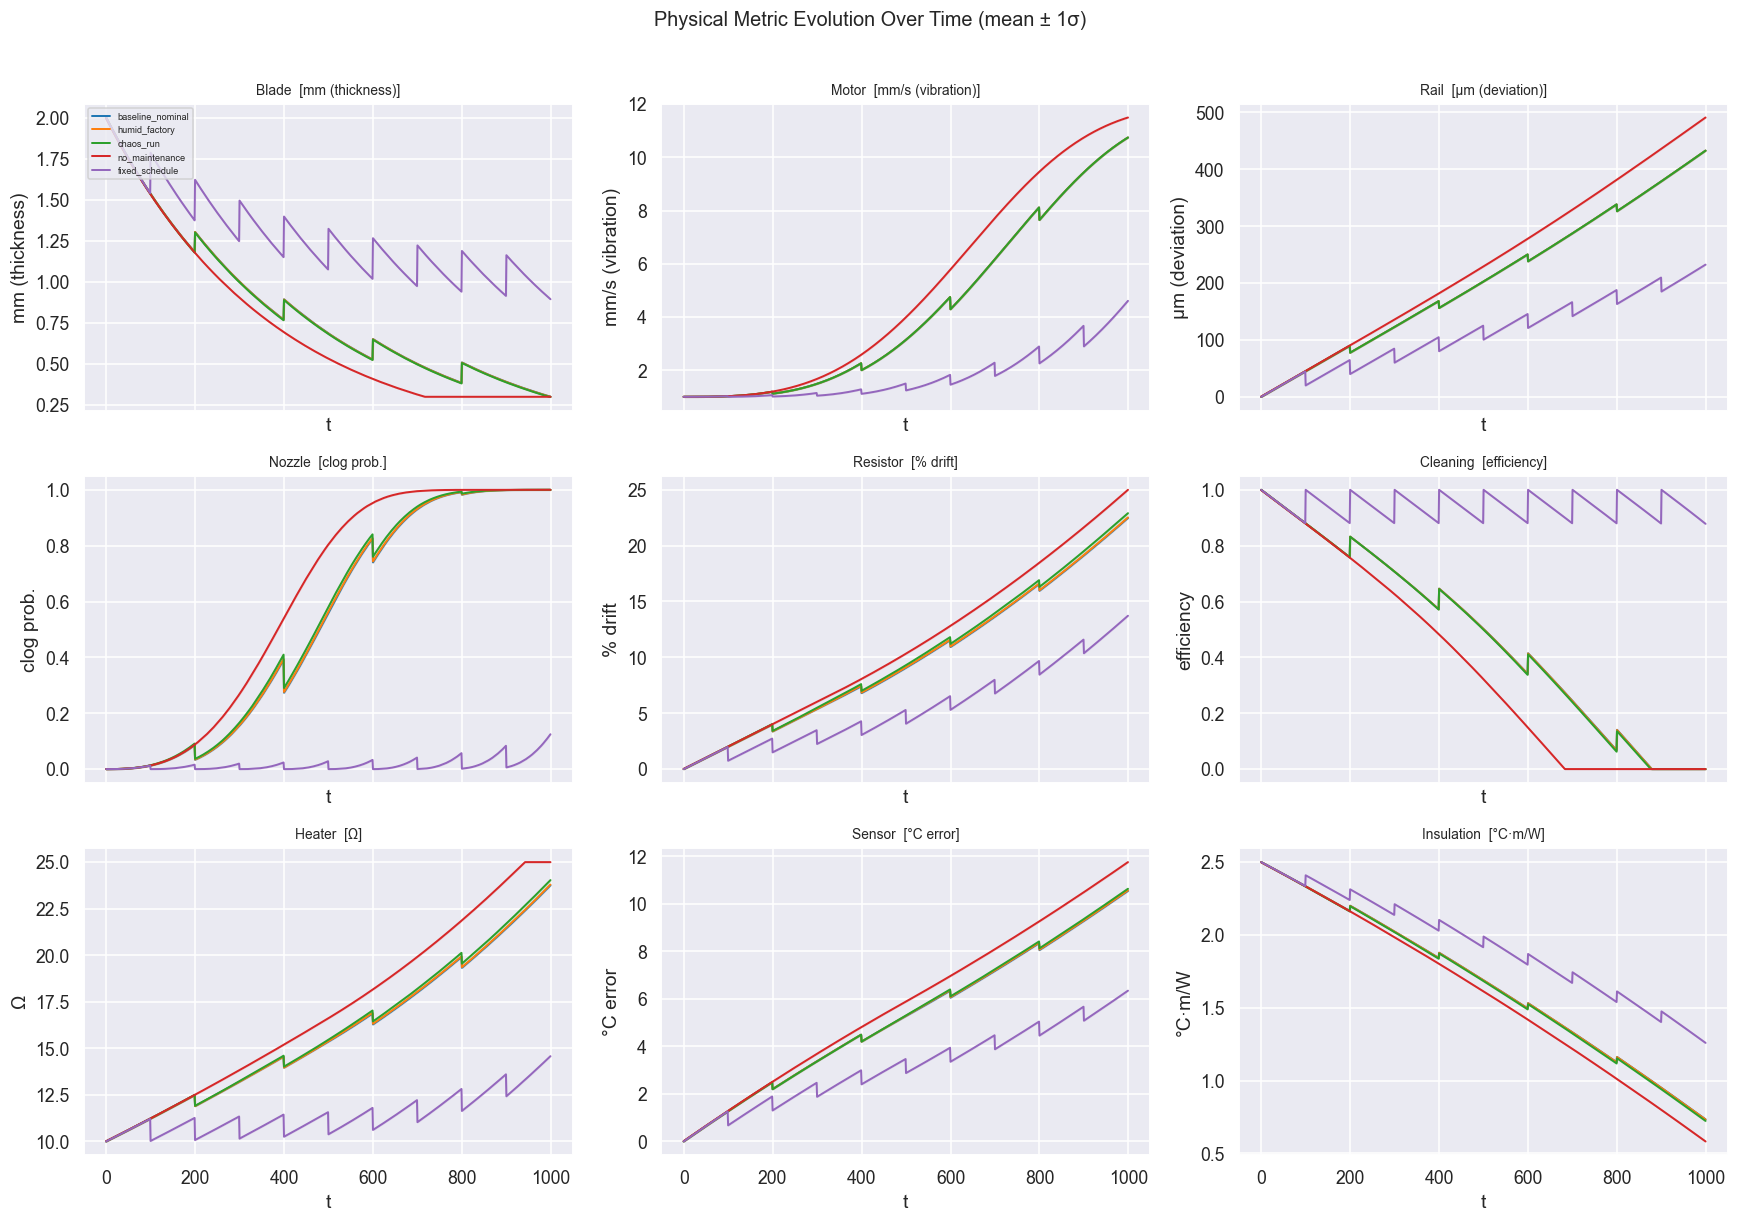

In [22]:

fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)

for ax, comp in zip(axes.ravel(), COMPONENTS):
    col  = METRICS[comp]
    unit = METRIC_UNITS[comp]
    for scen, color in zip(SCENARIOS, palette):
        grp = df[df["scenario_id"]==scen].groupby("t")[col]
        mn, sd = grp.mean(), grp.std()
        ax.plot(mn.index, mn.values, label=scen, color=color, linewidth=1.3)
        ax.fill_between(mn.index, mn-sd, mn+sd, alpha=0.1, color=color)
    ax.set_title(f"{comp.capitalize()}  [{unit}]", fontsize=9)
    ax.set_ylabel(unit); ax.set_xlabel("t")

axes[0][0].legend(fontsize=6, loc="upper left")
plt.suptitle("Physical Metric Evolution Over Time (mean ± 1σ)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


---
## 6 — Feature Correlation Analysis
### 6.1 — Pearson correlation: inputs → health indices


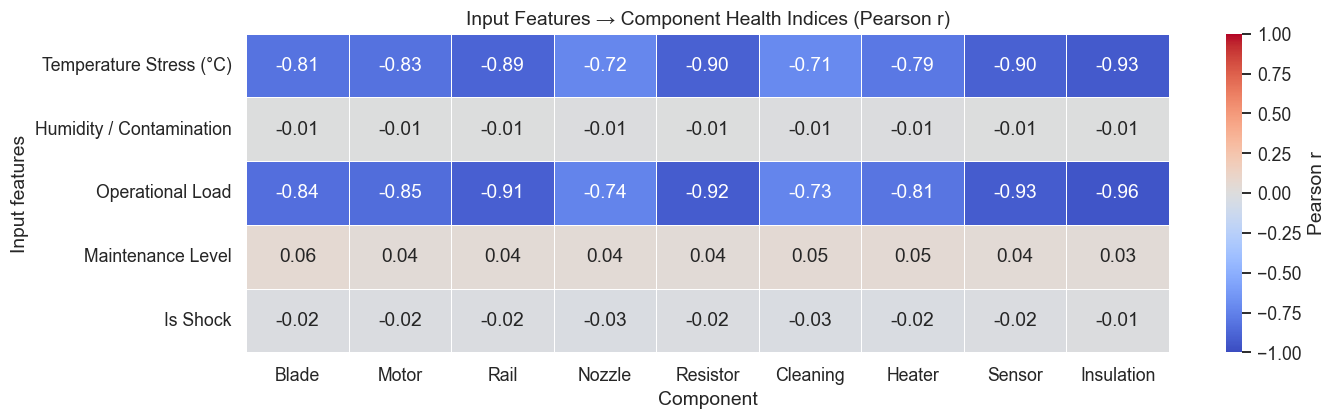

In [23]:

health_cols = [f"health_{c}" for c in COMPONENTS]
corr_cols   = INPUT_COLS + ["is_shock"] + health_cols

corr_matrix = df[corr_cols].corr()

# Sub-matrix: inputs → health
input_health_corr = corr_matrix.loc[INPUT_COLS + ["is_shock"], health_cols]
input_health_corr.columns = [c.capitalize() for c in COMPONENTS]
input_health_corr.index = INPUT_LABELS + ["Is Shock"]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(input_health_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"label":"Pearson r"})
ax.set_title("Input Features → Component Health Indices (Pearson r)")
ax.set_ylabel("Input features"); ax.set_xlabel("Component")
plt.tight_layout(); plt.show()


### 6.2 — Full correlation matrix (all inputs + all health outputs)


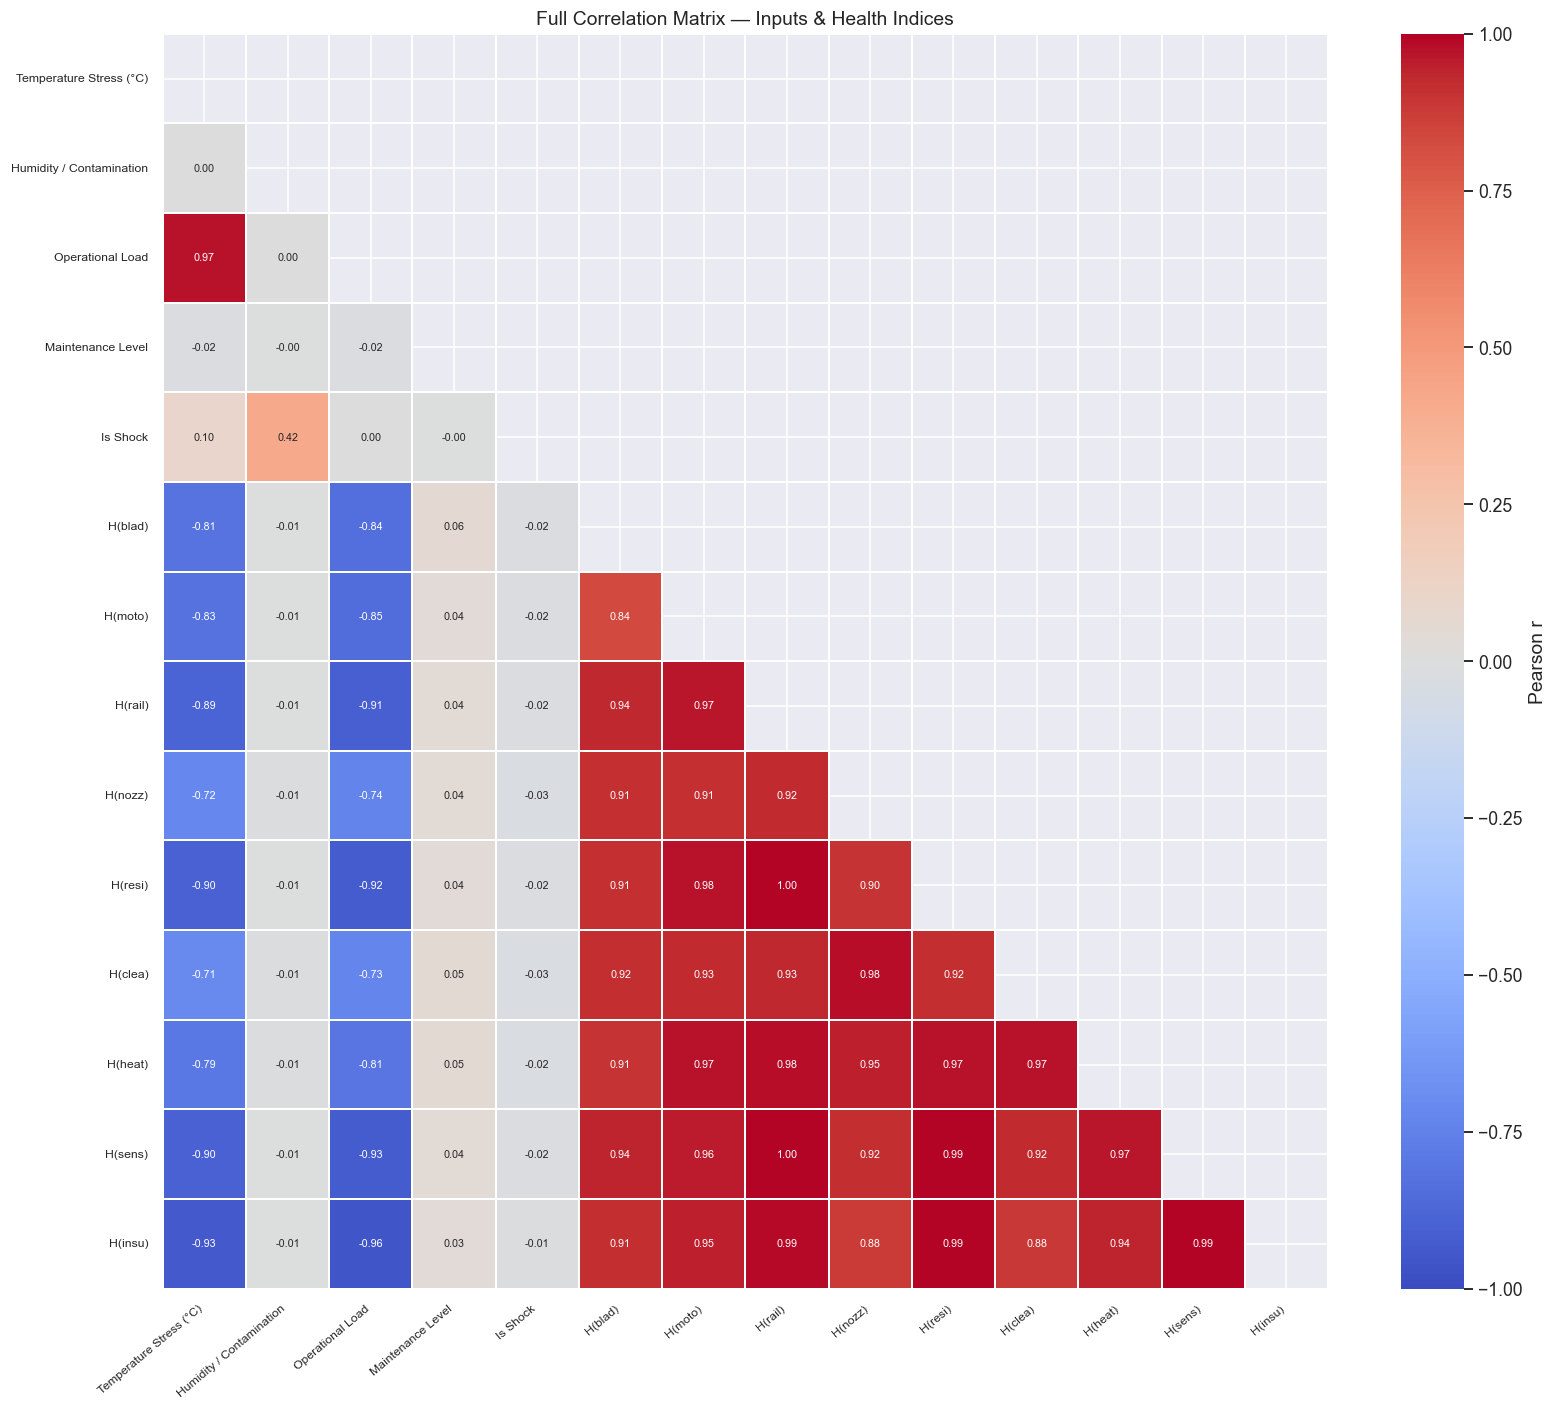

In [24]:

mask = np.triu(np.ones_like(corr_matrix.loc[corr_cols, corr_cols], dtype=bool))
fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr_matrix.loc[corr_cols, corr_cols], mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"})
nice_labels = INPUT_LABELS + ["Is Shock"] + [f"H({c[:4]})" for c in COMPONENTS]
ax.set_xticklabels(nice_labels, rotation=40, ha="right", fontsize=8)
ax.set_yticklabels(nice_labels, rotation=0, fontsize=8)
ax.set_title("Full Correlation Matrix — Inputs & Health Indices")
plt.tight_layout(); plt.show()


### 6.3 — Input vs. Health scatter (load & temperature stress, coloured by label)


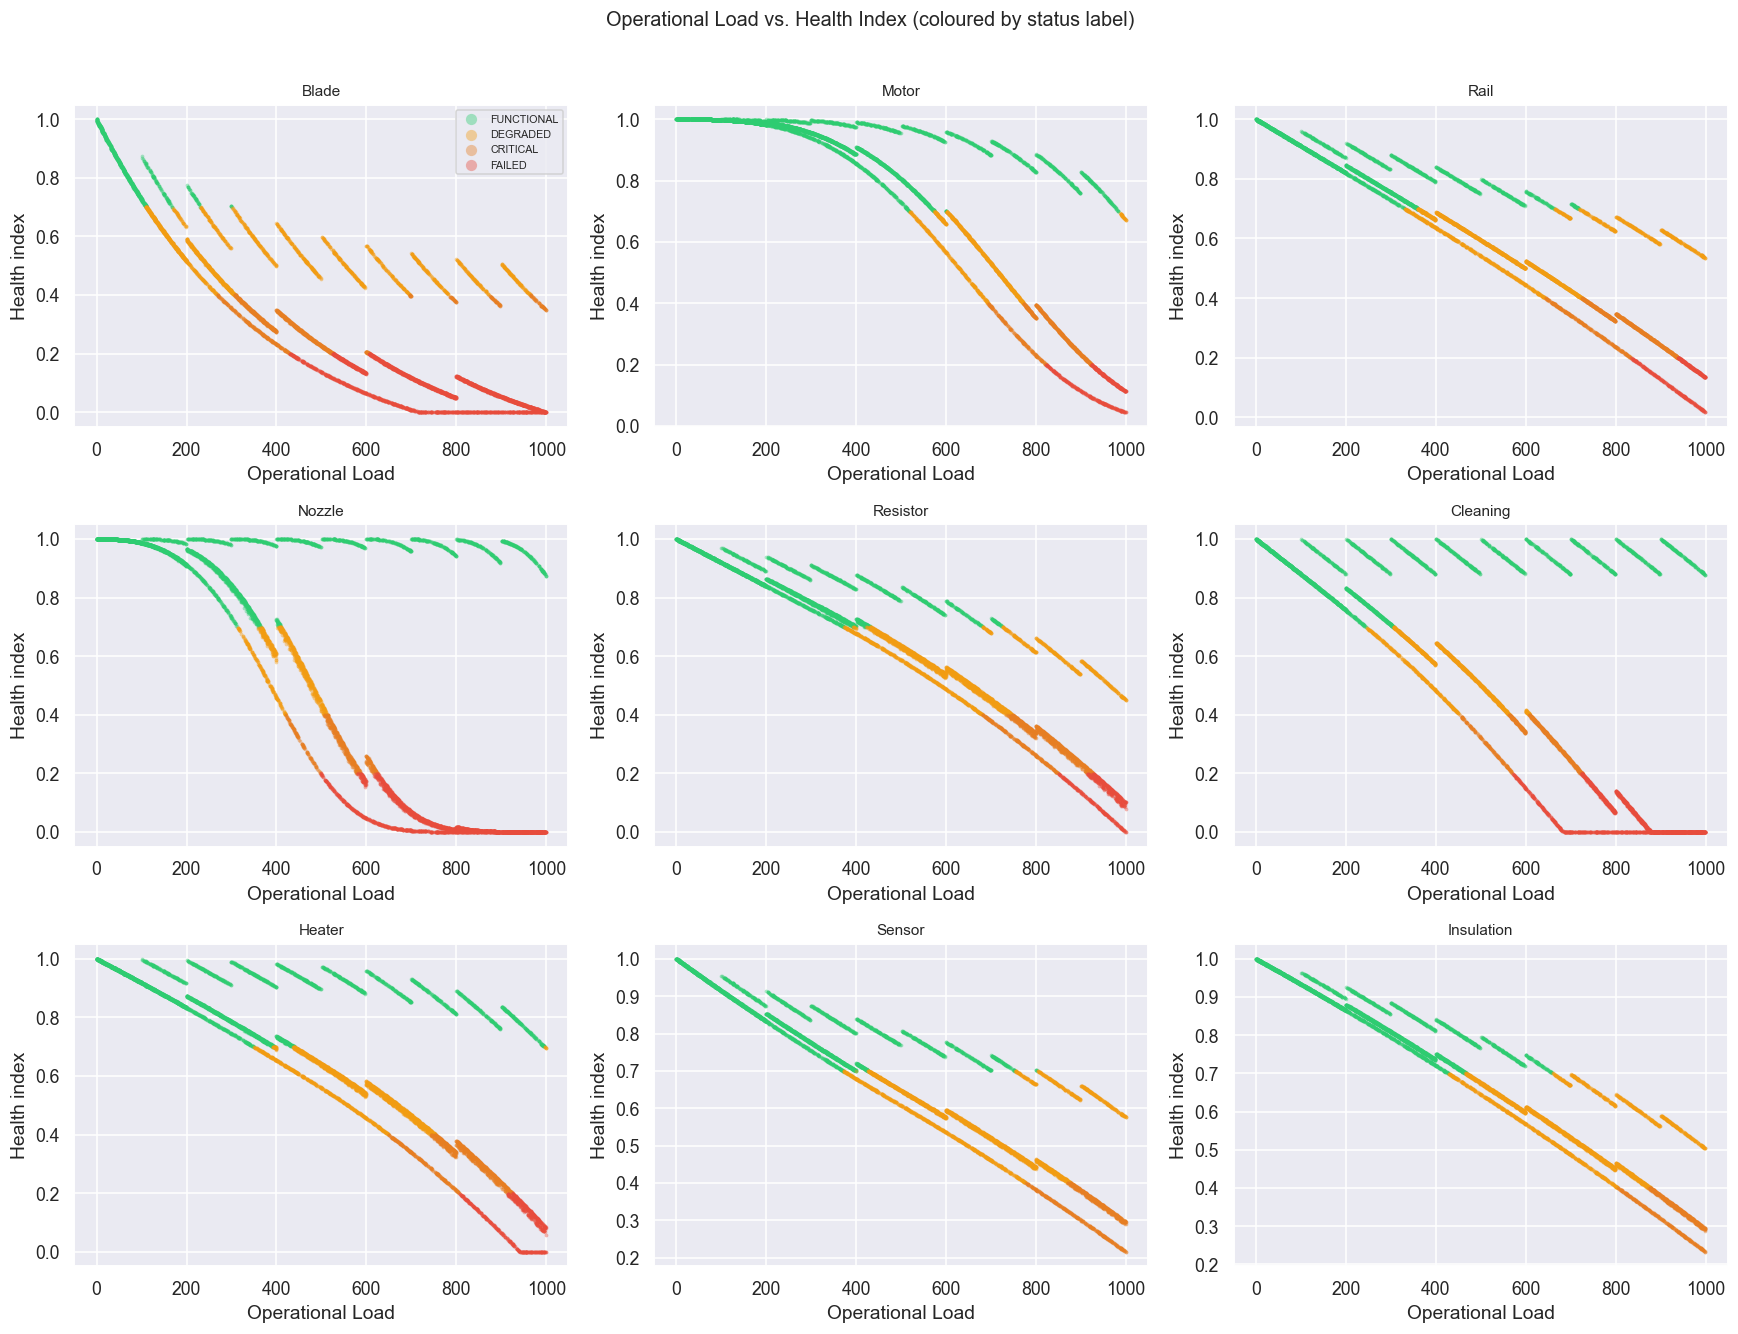

In [25]:

# Sample for readability
sample = df.sample(8000, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, comp in zip(axes.ravel(), COMPONENTS):
    hcol  = f"health_{comp}"
    lcol  = f"label_{comp}"
    sub   = sample[[hcol, "load", lcol]].dropna()
    sub[lcol] = sub[lcol].astype(int)

    for lbl in [0, 1, 2, 3]:
        mask = sub[lcol] == lbl
        ax.scatter(sub.loc[mask, "load"], sub.loc[mask, hcol],
                   c=LABEL_COLORS[lbl], label=LABEL_NAMES[lbl],
                   alpha=0.4, s=6, linewidths=0)
    ax.set_title(f"{comp.capitalize()}", fontsize=10)
    ax.set_xlabel("Operational Load"); ax.set_ylabel("Health index")

axes[0][0].legend(fontsize=7, markerscale=3)
plt.suptitle("Operational Load vs. Health Index (coloured by status label)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


---
## 7 — Summary Statistics Table


In [26]:

rows = []
for comp in COMPONENTS:
    hcol = f"health_{comp}"
    mcol = METRICS[comp]
    lcol = f"label_{comp}"
    h = df[hcol].dropna()
    m = df[mcol].dropna()
    failed_frac = (df[lcol]==3).mean()
    rows.append({
        "Component":       comp.capitalize(),
        "Subsystem":       next(ss for ss,cs in SUBSYSTEMS.items() if comp in cs),
        "Health μ":        round(h.mean(), 4),
        "Health σ":        round(h.std(),  4),
        "Health min":      round(h.min(),  4),
        "Health med":      round(h.median(), 4),
        "Metric μ":        round(m.mean(), 4),
        "Metric σ":        round(m.std(),  4),
        "Metric unit":     METRIC_UNITS[comp],
        "% FAILED":        f"{failed_frac*100:.1f}%",
        "% FUNCTIONAL":    f"{(df[lcol]==0).mean()*100:.1f}%",
    })

summary = pd.DataFrame(rows).set_index("Component")
summary


,Subsystem,Health μ,Health σ,Health min,Health med,Metric μ,Metric σ,Metric unit,% FAILED,% FUNCTIONAL
Component,,,,,,,,,,
Blade,Recoating,0.3523,0.2714,0.0000,0.3167,0.8989,0.4614,mm (thickness),39.5%,13.0%
Motor,Recoating,0.7342,0.2918,0.0455,0.8693,3.9243,3.2102,mm/s (vibration),8.1%,64.6%
Rail,Recoating,0.6115,0.2470,0.0177,0.6511,194.2538,123.5184,µm (deviation),7.0%,41.9%
Nozzle,Printhead,0.5529,0.4183,0.0000,0.6732,0.4471,0.4183,clog prob.,33.6%,48.6%
Resistor,Printhead,0.6288,0.2533,0.0003,0.6787,9.2802,6.3327,% drift,7.6%,47.2%
Cleaning,Printhead,0.5446,0.3540,0.0000,0.6118,0.5446,0.3540,efficiency,25.1%,43.3%
Heater,Thermal,0.6503,0.2727,0.0000,0.7174,15.2458,4.0904,Ω,8.6%,52.9%
Sensor,Thermal,0.6677,0.1959,0.2160,0.6892,4.9847,2.9387,°C error,0.0%,48.3%
Insulation,Thermal,0.6806,0.2001,0.2331,0.6986,1.7016,0.5001,°C·m/W,0.0%,49.8%
